In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import math
import pickle
from collections import Counter
import sys
import os

In [2]:
sys.path.append(os.path.abspath(".."))

from lago_data_model.model_utils import save_model

## Load Data

In [ ]:
# Reemplaza al huérfano "train_set_features.csv".
# pulses.csv lo genera eda.ipynb; aquí le quitamos las columnas posicionales
# (row_id, start_idx, min_idx, end_idx) para dejar sólo las 9 features físicas.
pulses_df = pd.read_csv("pulses.csv")
drop_cols = ["row_id", "start_idx", "min_idx", "end_idx"]
pulses_df = pulses_df.drop(columns=drop_cols, errors="ignore")
print("features:", list(pulses_df.columns))

In [4]:
pulses_df.shape

(4009941, 9)

In [5]:
pulses_df.head()

,min_value,baseline_local,depth,width_samples,area_under_pulse,fwhm_samples,rise_time,recovery_time,snr_depth_over_mad
0,113.0,195.0,82.0,12,528.0,6,3,8,13.666667
1,147.0,195.0,48.0,46,375.0,5,10,35,48.000000
2,157.0,195.0,38.0,153,396.0,5,76,76,38.000000
3,152.0,197.0,45.0,15,288.0,6,4,10,45.000000
4,155.0,196.0,41.0,23,339.0,8,7,15,41.000000


### Clean and Transform data

In [ ]:
# El drop de columnas posicionales ya se hizo al cargar pulses.csv.
# Esta celda queda como placeholder por compatibilidad con la estructura previa.

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pulses_df)

# Clustering con K-Means

KMeans codo: 100%|██████████| 8/8 [00:15<00:00,  1.97s/it]


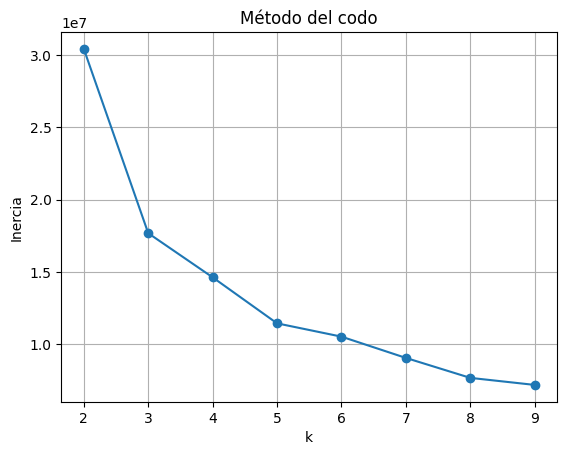

In [10]:
inertias = []
K_range = range(2, 10)
for k in tqdm(K_range, desc="KMeans codo"):
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker="o")
plt.title("Método del codo")
plt.grid()
plt.xlabel("k"); plt.ylabel("Inercia"); plt.show()

In [11]:
best_k = 5

### Train KMeans Model

In [12]:
kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=42)
labels = kmeans.fit_predict(X_scaled)
#pulses_df["cluster"] = labels

### PCA para visualización 2D/3D

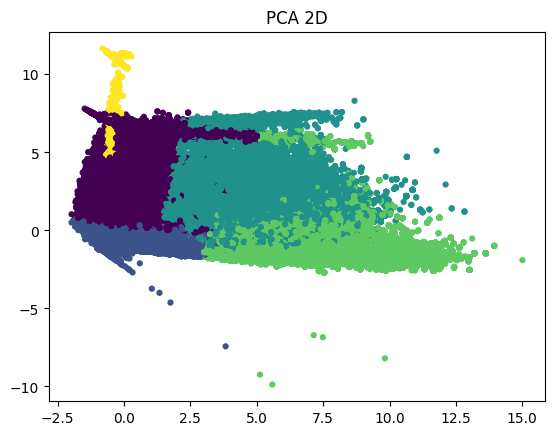

In [13]:
pca2 = PCA(n_components=2)
Xp2 = pca2.fit_transform(X_scaled)
plt.scatter(Xp2[:,0], Xp2[:,1], c=labels, s=12, cmap="viridis")
plt.title("PCA 2D"); plt.show()

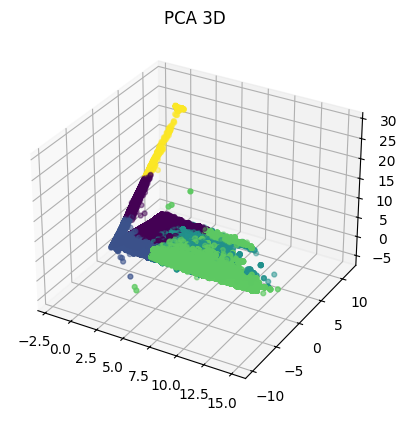

In [14]:
from mpl_toolkits.mplot3d import Axes3D
pca3 = PCA(n_components=3)
Xp3 = pca3.fit_transform(X_scaled)
fig = plt.figure(); ax = fig.add_subplot(111, projection="3d")
ax.scatter(Xp3[:,0], Xp3[:,1], Xp3[:,2], c=labels, s=12, cmap="viridis")
plt.title("PCA 3D"); plt.show()

In [15]:
def _cut_around_min(seg: np.ndarray, n_before: int, n_after: int):
    if len(seg) == 0:
        return seg
    kmin = int(np.argmin(seg))
    a = max(0, kmin - n_before)
    b = min(len(seg), kmin + n_after + 1)
    return seg[a:b]

def _align_and_normalize(seg: np.ndarray, align='min', normalize=True, scale=None, eps=1e-9):
    s = seg.astype(float).copy()
    if normalize:
        s = s - np.median(s)
    if scale == 'maxabs':
        m = np.max(np.abs(s))
        if m > eps:
            s = s / m
    elif scale == 'robust':
        p5, p95 = np.percentile(s, [5, 95])
        rng = p95 - p5
        if rng > eps:
            s = (s - p5) / rng
    return s

def _resample_to_fixed(seg: np.ndarray, out_len: int):
    L = len(seg)
    if L == 0:
        return np.zeros(out_len)
    if L == out_len:
        return seg
    x_old = np.linspace(0, 1, L)
    x_new = np.linspace(0, 1, out_len)
    return np.interp(x_new, x_old, seg)

def compare_pulse_segments_overlay(
    segments,labels,mode='same',
    classes=None,n=12,n_before=20,n_after=40,
    align='min',normalize=True,resample_len=120,
    show_median=True,title=None,
    rng_seed=42,ax=None, alpha=0.45, median_kwargs=None,      
    plot_kwargs=None, show_legend=True,        
    show_now=None,
    scale=None, # None | "maxabs" | "robust"
    y_percentile=None
):
    """
    Dibuja SÓLO los pulsos recortados alrededor del mínimo.
    Si 'ax' es None, crea su propia figura. Si 'ax' es un eje, dibuja ahí.
    Retorna: dict con {'ax', 'waves', 'median'} para reutilizar resultados.
    """
    labs = np.asarray(labels)
    if mode == 'same':
        if not classes or len(classes) != 1:
            raise ValueError("Para mode='same' usa classes=[clase].")
        c = classes[0]
        idx = np.where(labs == c)[0]
        title = title or f"Pulsos superpuestos (misma clase {c})"
    else:
        if not classes or len(classes) < 2:
            uniq = np.unique(labs)
            classes = list(uniq[:2])
        idx = np.concatenate([np.where(labs == c)[0] for c in classes])
        title = title or f"Pulsos superpuestos (clases {classes})"

    if len(idx) == 0:
        print("No hay pulsos para los criterios indicados.")
        return {'ax': ax, 'waves': [], 'median': None}

    rng = np.random.default_rng(rng_seed)
    idx = rng.choice(idx, size=min(n, len(idx)), replace=False)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,4))
        created_fig = True

    waves = []
    _plot_kwargs = dict()
    if plot_kwargs:
        _plot_kwargs.update(plot_kwargs)

    for k in idx:
        seg = np.asarray(segments[k]).astype(float)
        seg = _cut_around_min(seg, n_before=n_before, n_after=n_after)
        seg = _align_and_normalize(seg, align=align, normalize=normalize, scale=scale)
        seg = _resample_to_fixed(seg, out_len=resample_len)
        waves.append(seg)
        ax.plot(seg, alpha=alpha, **_plot_kwargs)

    med = None
    if show_median and len(waves) > 0:
        med = np.median(np.vstack(waves), axis=0)
        mk = dict(lw=2.5, label="Mediana", zorder=10)
        if median_kwargs:
            mk.update(median_kwargs)
        ax.plot(med, **mk)

    # Ajuste de Y por percentiles (por subplot)
    if y_percentile is not None and len(waves) > 0:
        lo, hi = np.percentile(np.hstack(waves), y_percentile)
        if lo == hi:  # evita colapso si todos son iguales
            lo -= 1.0
            hi += 1.0
        ax.set_ylim(lo, hi)

    ax.set_title(title)
    ax.set_xlabel("Muestras (re-muestreadas)")
    ax.set_ylabel("Amplitud normalizada" if normalize else "Amplitud")
    if show_median and show_legend:
        ax.legend()
    ax.grid(True)
    plt.tight_layout()

    # Decidir si llamar plt.show()
    if show_now is None:
        # Si nosotros creamos la figura, mostramos; si no, dejamos al caller.
        show_now = created_fig
    if show_now and created_fig:
        plt.show()

    return {'ax': ax, 'waves': waves, 'median': med}


def compare_pulse_subplots(
    segments, labels, classes_list,
    ncols=3, figsize=(12, 4), sharey=False, **kwargs
):
    n = len(classes_list)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=sharey)
    axes = np.atleast_1d(axes).ravel()

    for i, c in enumerate(classes_list):
        compare_pulse_segments_overlay(
            segments, labels,
            mode='same', classes=[c],
            ax=axes[i],
            show_now=False,
            show_legend=(i == 0),
            **kwargs
        )
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    return axes

In [16]:
#compare_pulse_segments_overlay(
#    segments, labels,
#    mode='same', classes=[1],
#    n=15, n_before=20, n_after=40,
#    align='min', normalize=True, resample_len=120, show_median=True
#)

In [ ]:
# Reemplaza al huérfano "training_set.pkl".
# all_segments.pkl es lista de dicts {'start','end','min_idx','values'}; el helper
# de abajo espera arrays planos, así que extraemos sólo los 'values'.
with open("all_segments.pkl", "rb") as f:
    all_segments = pickle.load(f)
segments = [np.asarray(s["values"]) for s in all_segments]
print("segments cargados:", len(segments))

No hay pulsos para los criterios indicados.


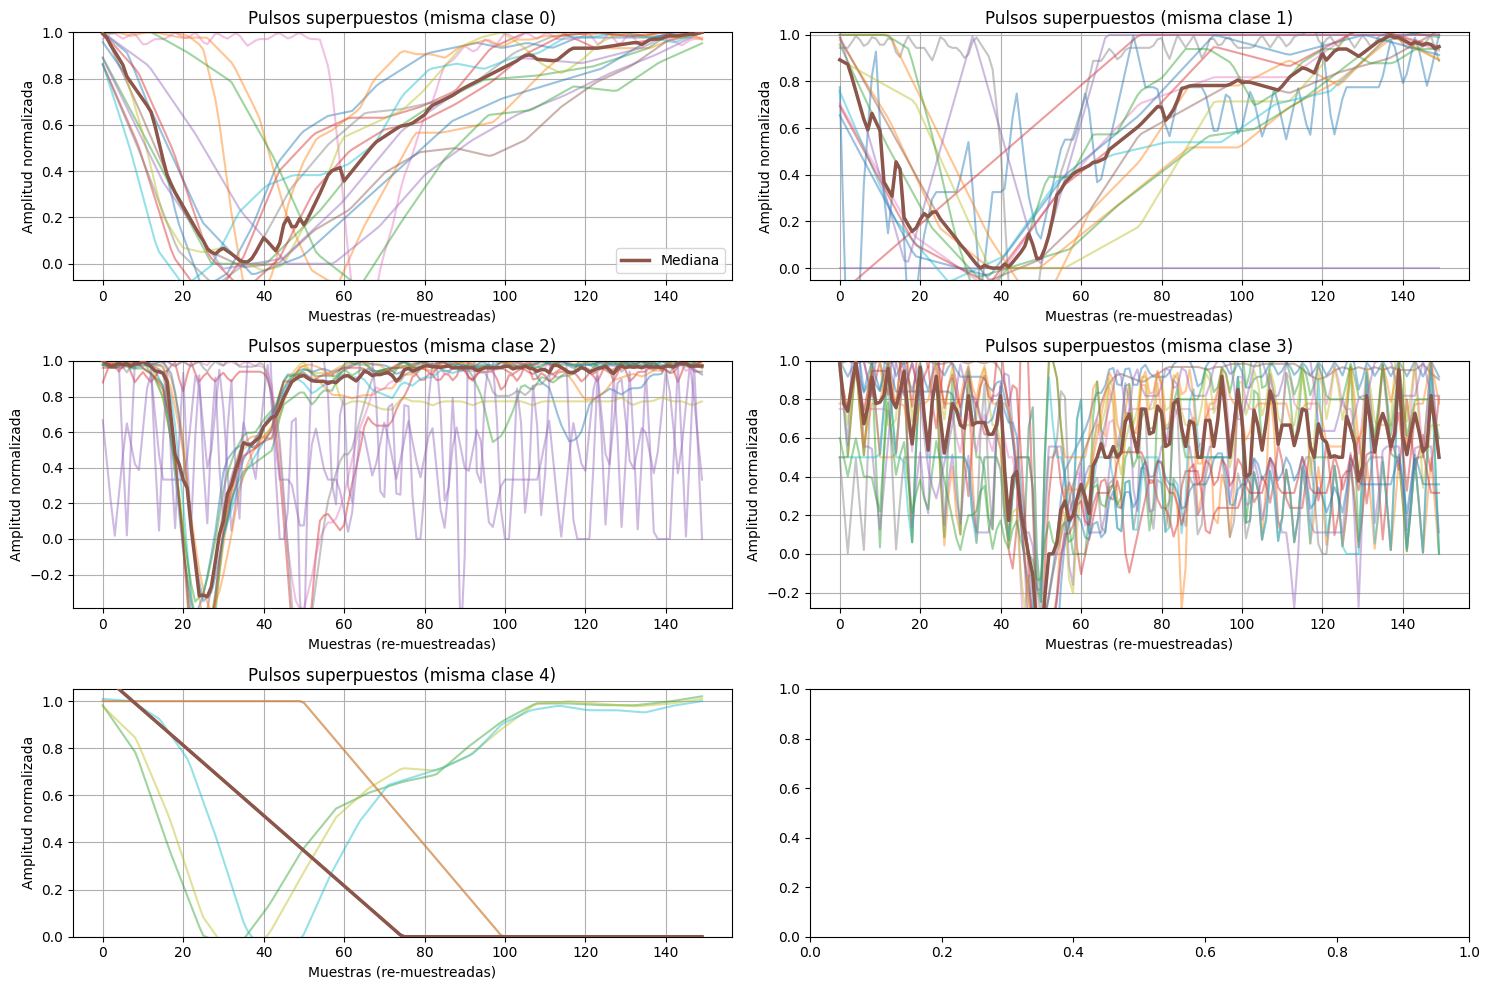

array([<Axes: title={'center': 'Pulsos superpuestos (misma clase 0)'}, xlabel='Muestras (re-muestreadas)', ylabel='Amplitud normalizada'>,
       <Axes: title={'center': 'Pulsos superpuestos (misma clase 1)'}, xlabel='Muestras (re-muestreadas)', ylabel='Amplitud normalizada'>,
       <Axes: title={'center': 'Pulsos superpuestos (misma clase 2)'}, xlabel='Muestras (re-muestreadas)', ylabel='Amplitud normalizada'>,
       <Axes: title={'center': 'Pulsos superpuestos (misma clase 3)'}, xlabel='Muestras (re-muestreadas)', ylabel='Amplitud normalizada'>,
       <Axes: title={'center': 'Pulsos superpuestos (misma clase 4)'}, xlabel='Muestras (re-muestreadas)', ylabel='Amplitud normalizada'>,
       <Axes: >], dtype=object)

In [18]:
compare_pulse_subplots(
    segments, labels,
    classes_list=[0,1,2,3,4,5],
    ncols=2, figsize=(15,10),
    n=15, n_before=25, n_after=50,
    resample_len=150, normalize=True,
    scale="robust", y_percentile=(2, 98)
)

In [19]:

element_counts = Counter(labels)
print(f"Counts of all elements : {element_counts}")

Counts of all elements : Counter({1: 2325834, 0: 1332681, 3: 192956, 2: 153687, 4: 4783})


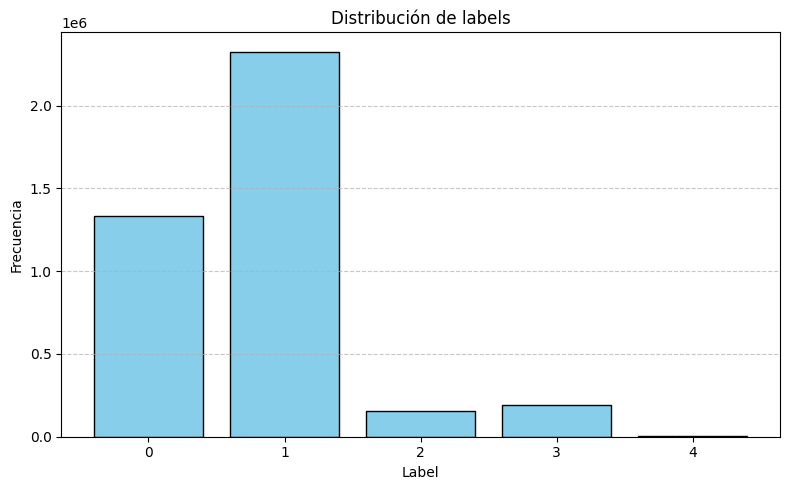

In [20]:
unique, counts = np.unique(labels, return_counts=True)

# Gráfico de barras
plt.figure(figsize=(8, 5))
plt.bar(unique, counts, color='skyblue', edgecolor='black')
plt.title("Distribución de labels")
plt.xlabel("Label")
plt.ylabel("Frecuencia")
plt.xticks(unique)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Save models

In [21]:
save_model(kmeans, "models/kmeans.pkl")

2025-11-28 20:10:42.946197: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-28 20:10:43.269366: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-28 20:10:43.417914: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-28 20:10:43.459895: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-28 20:10:43.693167: I tensorflow/core/platform/cpu_feature_guar

[save_model] sklearn guardado en: models/kmeans_2025-11-28_20-10-41.pkl


'models/kmeans_2025-11-28_20-10-41.pkl'

## Save labels

In [22]:
with open('kmeans_labels.pkl', 'wb') as handle:
    pickle.dump(labels, handle, protocol=pickle.HIGHEST_PROTOCOL)